In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import animation
from IPython.display import HTML, Image, display

try:
    from matplotlib.animation import PillowWriter
    HAS_PILLOW = True
except Exception:
    HAS_PILLOW = False

L = 1.0  
c = 1.0      
Nx = 200    
dx = L / Nx
x = np.linspace(0.0, L, Nx + 1)

A = 1.0


In [2]:
def triangular_pluck(x, L=1.0, A=1.0):
    left = (x <= L/2)
    f = np.empty_like(x)
    f[left] = (2*A/L) * x[left]
    f[~left] = (2*A/L) * (L - x[~left])
    return f

def g_zero(x):
    return np.zeros_like(x)

f0 = triangular_pluck(x, L=L, A=A)
g0 = g_zero(x)


In [3]:
def simulate_wave(CFL=0.5, T_final=1.0, store_frames=True, frame_cap=150):
    dt = CFL * dx / c
    lam = CFL
    n_steps = int(np.ceil(T_final / dt))
    step_skip = max(1, n_steps // frame_cap)

    u_prev = f0.copy()
    u_prev[0] = 0.0
    u_prev[-1] = 0.0

    u_curr = u_prev.copy()
    uxx0 = (u_prev[2:] - 2*u_prev[1:-1] + u_prev[:-2]) / dx**2
    u_curr[1:-1] = u_prev[1:-1] + dt * g0[1:-1] + 0.5 * (c**2) * (dt**2) * uxx0
    u_curr[0] = 0.0
    u_curr[-1] = 0.0

    frames = [u_prev.copy()] if store_frames else None
    times = [0.0]
    max_abs = [float(np.max(np.abs(u_prev)))]

    t = 0.0
    for n in range(1, n_steps):
        u_next = np.empty_like(u_curr)
        u_next[1:-1] = (
            2*u_curr[1:-1] - u_prev[1:-1]
            + (lam**2) * (u_curr[2:] - 2*u_curr[1:-1] + u_curr[:-2])
        )
        u_next[0] = 0.0
        u_next[-1] = 0.0

        t += dt
        times.append(t)
        max_abs.append(float(np.max(np.abs(u_next))))

        if store_frames and (n % step_skip == 0):
            frames.append(u_next.copy())

        u_prev, u_curr = u_curr, u_next

    meta = {
        "dt": dt, "dx": dx, "CFL": CFL,
        "n_steps": n_steps,
        "frames_recorded": (len(frames) if store_frames else 0),
    }
    return (np.array(frames) if store_frames else None), np.array(times), np.array(max_abs), meta


In [4]:
def animate_frames(frames, meta, interval_ms=35):
    fig, ax = plt.subplots(figsize=(7.5, 3.0))
    line, = ax.plot(x, frames[0])
    ax.set_xlim(0.0, L)
    lo = np.percentile(frames, 1.0)
    hi = np.percentile(frames, 99.0)
    pad = 0.05 * max(1.0, (hi - lo))
    ax.set_ylim(lo - pad, hi + pad)
    ax.set_xlabel("x")
    ax.set_ylabel("u(x,t)")
    ax.set_title(f"1D wave | explicit central | CFL={meta['CFL']:.2f}, dx={meta['dx']:.4f}, dt={meta['dt']:.5e}")

    def init():
        line.set_data(x, frames[0])
        return (line,)

    def update(i):
        line.set_data(x, frames[i])
        return (line,)

    anim = animation.FuncAnimation(fig, update, init_func=init, frames=len(frames), interval=interval_ms, blit=True)
    plt.close(fig)
    return anim

def display_animation(anim, prefer="gif", save_path="wave_anim.gif", fps=30):
    if prefer == "gif" and HAS_PILLOW:
        try:
            writer = PillowWriter(fps=fps)
            anim.save(save_path, writer=writer)
            display(Image(filename=save_path))
            print("Saved GIF to:", save_path)
            return
        except Exception as e:
            print("GIF save failed, falling back to HTML. Reason:", repr(e))

    html = anim.to_jshtml()
    display(HTML(html))
    print("Displayed as HTML (jshtml).")


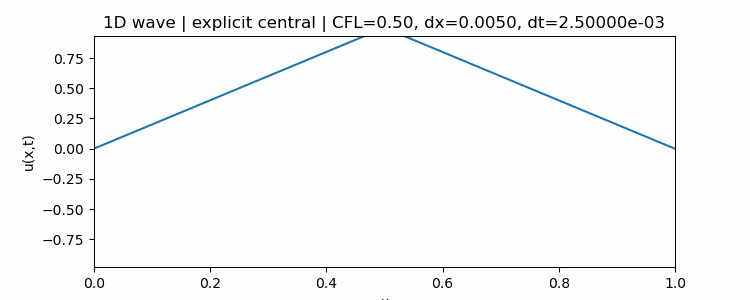

Saved GIF to: wave_cfl_0.50.gif
dx = 0.005 | dt = 0.0025 | n_steps = 480 | frames = 160


In [5]:
frames, times, maxabs, meta = simulate_wave(CFL=0.50, T_final=1.2, store_frames=True, frame_cap=140)
anim = animate_frames(frames, meta, interval_ms=35)
display_animation(anim, prefer="gif", save_path="wave_cfl_0.50.gif", fps=25)

print("dx =", dx, "| dt =", meta["dt"], "| n_steps =", meta["n_steps"], "| frames =", meta["frames_recorded"])


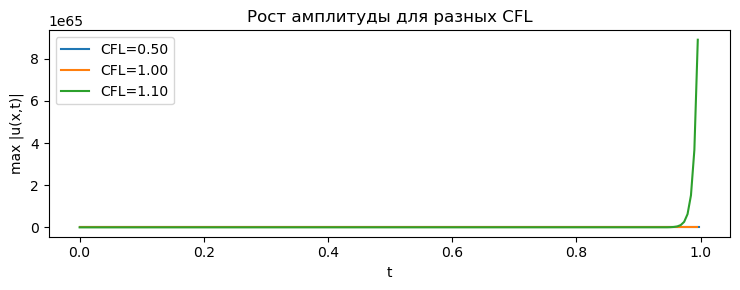

In [6]:
curves = []
for cfl in (0.50, 1.00, 1.10):
    _, t, mabs, meta = simulate_wave(CFL=cfl, T_final=1.0, store_frames=False)
    curves.append((cfl, t, mabs, meta))

plt.figure(figsize=(7.5, 3.0))
for cfl, t, mabs, meta in curves:
    plt.plot(t, mabs, label=f"CFL={cfl:.2f}")
plt.xlabel("t")
plt.ylabel("max |u(x,t)|")
plt.title("Рост амплитуды для разных CFL")
plt.legend()
plt.tight_layout()
plt.show()


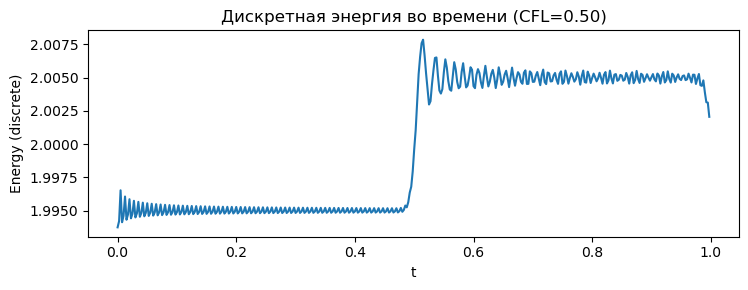

In [7]:
def simulate_wave_energy(CFL=0.5, T_final=1.0):
    dt = CFL * dx / c
    lam = CFL
    n_steps = int(np.ceil(T_final / dt))

    u_prev = f0.copy()
    u_prev[0] = 0.0
    u_prev[-1] = 0.0

    u_curr = u_prev.copy()
    uxx0 = (u_prev[2:] - 2*u_prev[1:-1] + u_prev[:-2]) / dx**2
    u_curr[1:-1] = u_prev[1:-1] + dt * g0[1:-1] + 0.5 * (c**2) * (dt**2) * uxx0
    u_curr[0] = 0.0
    u_curr[-1] = 0.0

    times = [0.0, dt]
    energy = []

    def discrete_energy(u_n, u_nm1):
        ut = (u_n - u_nm1) / dt
        ux = (u_n[1:] - u_n[:-1]) / dx
        e = 0.5 * (np.sum(ut**2) * dx + (c**2) * np.sum(ux**2) * dx)
        return float(e)

    energy.append(discrete_energy(u_curr, u_prev))

    t = dt
    for n in range(1, n_steps):
        u_next = np.empty_like(u_curr)
        u_next[1:-1] = (
            2*u_curr[1:-1] - u_prev[1:-1]
            + (lam**2) * (u_curr[2:] - 2*u_curr[1:-1] + u_curr[:-2])
        )
        u_next[0] = 0.0
        u_next[-1] = 0.0

        energy.append(discrete_energy(u_next, u_curr))

        t += dt
        times.append(t)
        u_prev, u_curr = u_curr, u_next

    return np.array(times[:len(energy)]), np.array(energy)

tE, E = simulate_wave_energy(CFL=0.50, T_final=1.0)
plt.figure(figsize=(7.5, 3.0))
plt.plot(tE, E)
plt.xlabel("t")
plt.ylabel("Energy (discrete)")
plt.title("Дискретная энергия во времени (CFL=0.50)")
plt.tight_layout()
plt.show()
